In [1]:
from dataMaker import DataHandler
import plotter
import dataLoader

import matplotlib.pyplot as plt
import numpy as np

### Data Paths

In [2]:
TRAIN_DATA_PATH = '/workspace/data/cv_project/grid_data_train.h5'
VAL_DATA_PATH = '/workspace/data/cv_project/grid_data_val.h5'
MAT_DATA_PATH = '/workspace/data/cv_project/grid_data.mat'
MAT_NOISE_DATA_PATH = '/workspace/data/cv_project/noise_only_data.mat'

### Generate Spectrogams

In [ ]:
# Load simulated data into data object
handler = DataHandler(path=MAT_DATA_PATH, noise_only_path=MAT_NOISE_DATA_PATH)

# Make each audio waveform have mean=0 and var=1
handler.normalize_wav()

# Create spectrograms
handler.create_spectrograms(rand_shift=True, nperseg=60, noverlap=52, nfft=736, verbose=True)

# Save data
handler.save_split_h5(train_path=TRAIN_DATA_PATH, val_path=VAL_DATA_PATH, train_size=0.8, shuffle=True)

del handler

### Visualize Data

Load the validation data.

In [3]:
X, y = dataLoader.load_h5(VAL_DATA_PATH)

Plot the different classes

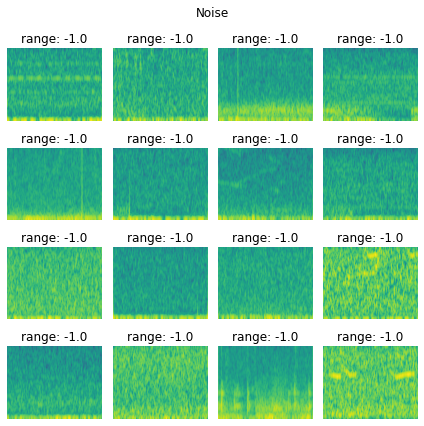

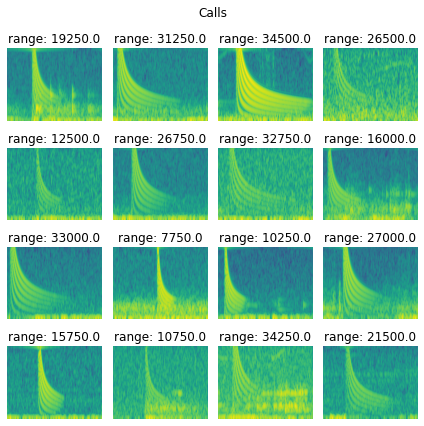

In [4]:
plotter.plot_grid(X[np.where(y[:,0] == -1)], y[np.where(y[:,0] == -1),0].squeeze(), "range", "Noise", dim=(4,4))
plotter.plot_grid(X[np.where(y[:,0] != -1)], y[np.where(y[:,0] != -1),0].squeeze(), "range", "Calls", dim=(4,4))